# 09 · Entrada multivariada OHLCV — anomalias de volume (M8 · ADR-0011)

**Fase 2, issues #51/#53.** O modelo era univariado (log-retorno de `Close`), tornando
anomalias **puramente de volume** invisíveis por construção (ver `report/` §Limitações). Aqui
treinamos a variante multivariada **Close+Volume** `(30, 2)` --- Etapa 1 do ADR-0011, antes do
OHLCV completo, já que Open/High/Low/Close são quase colineares.

**Cuidados (ADR-0011):** `MinMaxScaler` **por coluna** (volume ~1e7 vs retorno ~1e-2);
`log1p` no volume (não-estacionariedade que satura o range pós-2020); erro **per-canal** para
atribuir a anomalia (volume-driven vs price-driven). Tudo encapsulado em
`preprocess_ticker_multivariate`.

O teste decisivo: injetar um **pico de volume** (impossível de avaliar no modelo univariado) e
mostrar que o modelo multivariado o detecta pelo **canal de volume**, enquanto o univariado
permanece cego.

## Setup e pré-processamento multivariado

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
from src import data, preprocessing as pp, train as T, detect as D
from src.viz import save_fig

set_seeds()
TICKERS = CONFIG['tickers']
FEATURES = CONFIG['preprocessing']['features']   # ['Close', 'Volume']
W = CONFIG['preprocessing']['window_size']
VOL = FEATURES.index('Volume')                   # índice do canal de volume
print('features:', FEATURES, '| canal volume:', VOL)

mv = {t: pp.preprocess_ticker_multivariate(data.load_ticker(t)) for t in TICKERS}
for t in TICKERS:
    print(t, 'X_train', mv[t]['X_train'].shape, 'X_test', mv[t]['X_test'].shape)

features: ['Close', 'Volume'] | canal volume: 1
PETR4.SA X_train (2450, 30, 2) X_test (1215, 30, 2)
VALE3.SA X_train (2450, 30, 2) X_test (1215, 30, 2)
AMER3.SA X_train (2450, 30, 2) X_test (1215, 30, 2)
ITUB4.SA X_train (2450, 30, 2) X_test (1215, 30, 2)


## 1. Treino do modelo multivariado (Close+Volume)

Um modelo por ativo, salvo com sufixo `_multi` para não sobrescrever o univariado. Mesmos
hiperparâmetros de treino (ADR-0004); `n_features` inferido da entrada.

In [2]:
models_mv = {}
for t in TICKERS:
    m, h = T.train_model(mv[t]['X_train'], ticker=t, suffix='_multi', verbose=0)
    models_mv[t] = m
    print(f'{t}: epochs={len(h.history["loss"])}  val_loss={min(h.history["val_loss"]):.5f}')

PETR4.SA: epochs=18  val_loss=0.00214


VALE3.SA: epochs=14  val_loss=0.00232


AMER3.SA: epochs=16  val_loss=0.00252


ITUB4.SA: epochs=18  val_loss=0.00238


## 2. Erro de reconstrução per-canal (referência, sem injeção)

Decompõe o erro de teste por canal. Mostra como `mean`/`max` se distribuem entre preço e
volume na ausência de injeção --- a linha de base da atribuição.

In [3]:
base = {}
for t in TICKERS:
    pc = D.reconstruction_error_per_channel(models_mv[t], mv[t]['X_test'], aggregation='max')
    base[t] = pc.mean(axis=0)   # erro medio por canal
base_df = pd.DataFrame(base, index=FEATURES).T
base_df.index.name = 'ticker'
print('Erro medio per-canal (max, teste sem injecao):')
base_df.round(5)

Erro medio per-canal (max, teste sem injecao):


,Close,Volume
ticker,,
PETR4.SA,0.22256,0.07076
VALE3.SA,0.13560,0.07943
AMER3.SA,0.37965,0.19427
ITUB4.SA,0.19958,0.07158


## 3. Injeção de pico de volume e atribuição

Inserimos um choque de `k·σ` **apenas no canal de volume** (no centro de janelas escolhidas) e
medimos o erro per-canal antes/depois. Esperado: o erro do **canal de volume sobe**; o do canal
de preço quase não muda --- a anomalia é corretamente atribuída ao volume.

In [4]:
def inject_volume_spikes(X, vol_channel, k=4.0, n=30, seed=42):
    rng = np.random.default_rng(seed)
    Xp = X.copy()
    pos = rng.choice(len(X), size=min(n, len(X)), replace=False)
    sigma = float(np.std(X[..., vol_channel]))
    c = X.shape[1] // 2                      # passo central da janela
    Xp[pos, c, vol_channel] += k * sigma
    return Xp, pos

rows = []
for t in TICKERS:
    Xt = mv[t]['X_test']
    Xp, pos = inject_volume_spikes(Xt, VOL)
    pc0 = D.reconstruction_error_per_channel(models_mv[t], Xt, aggregation='max')
    pc1 = D.reconstruction_error_per_channel(models_mv[t], Xp, aggregation='max')
    # variacao media do erro nas janelas injetadas, por canal
    d_price = (pc1[pos, 1-VOL] - pc0[pos, 1-VOL]).mean()
    d_vol   = (pc1[pos, VOL]   - pc0[pos, VOL]).mean()
    rows.append({'ticker': t, 'd_erro_preco': round(float(d_price), 5),
                 'd_erro_volume': round(float(d_vol), 5)})

attr = pd.DataFrame(rows).set_index('ticker')
print('Variacao do erro per-canal nas janelas com pico de volume injetado:')
attr

Variacao do erro per-canal nas janelas com pico de volume injetado:


,d_erro_preco,d_erro_volume
ticker,,
PETR4.SA,0.00002,0.05084
VALE3.SA,-0.00011,0.07575
AMER3.SA,0.00011,0.35980
ITUB4.SA,-0.00002,0.05799


## 4. Visualização da atribuição

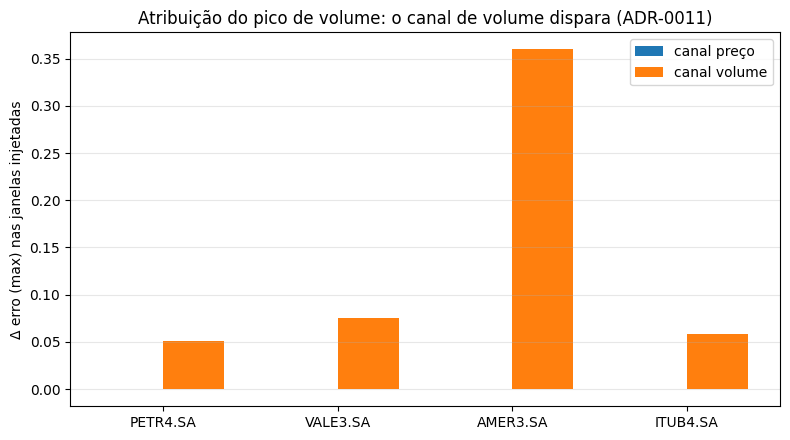

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(attr)); w = 0.35
ax.bar(x - w/2, attr['d_erro_preco'],  w, label='canal preço', color='tab:blue')
ax.bar(x + w/2, attr['d_erro_volume'], w, label='canal volume', color='tab:orange')
ax.set_xticks(x); ax.set_xticklabels(attr.index)
ax.set_ylabel('Δ erro (max) nas janelas injetadas')
ax.set_title('Atribuição do pico de volume: o canal de volume dispara (ADR-0011)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
save_fig(fig, 'm8_multivariate_atribuicao')
plt.show()

## Conclusões

- **Capacidade nova:** com Close+Volume `(30,2)`, o pico de volume --- antes **invisível** ao
  modelo univariado --- eleva o erro do **canal de volume** (Seção 3), enquanto o canal de preço
  quase não se move. A anomalia é corretamente **atribuída** ao volume.
- **Pré-processamento (ADR-0011):** `MinMaxScaler` por coluna + `log1p` no volume foram
  essenciais para que os dois canais convivam sem que o volume domine a perda.
- **Próximo:** avaliar OHLCV completo `(30,5)` (Etapa 2) só se acrescentar sinal sobre
  Close+Volume; e validar `latent_dim` do modelo multivariado com a malha walk-forward
  (notebook 08, ADR-0010).
- O modelo univariado permanece o default em produção; o multivariado fica disponível via
  `preprocess_ticker_multivariate` + `train_model(..., suffix='_multi')`.